# Real, or the usual wobble?

**Week 1, Thursday. Notebook 1 of 3, round 1.** By the end of this notebook you can run a shuffle
test on two quarters, read its share as a p-value, and write the one sentence a p-value supports.

> **The client asks.** "Retail-Plus is down, smaller than first reported. Real, or the wobble we see
> every quarter?"
>
> Meera Raghavan, CEO, Kalpa Retail

> **Kavya's review, before you start.** "Show me what an ordinary quarter looks like first. Then
> show me the gap against it. I will read your sentence before I read your number."

Wednesday reconciled the quarters with Finance and left Retail-Plus standing, but smaller. This
notebook asks whether what is left is bigger than chance makes on its own. The measure is delivered
revenue per member per quarter: Monday settled that cancelled and returned orders are not money
kept, and a member is the unit that exists in both quarters.

**Setup.** Find the helper and load the cleaned two quarters. The file is Wednesday's reconciled
export, so nothing here needs cleaning again.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
print(len(ORDERS), "orders,", len({o["customer_id"] for o in ORDERS}), "customers, two quarters")

186 orders, 69 customers, two quarters


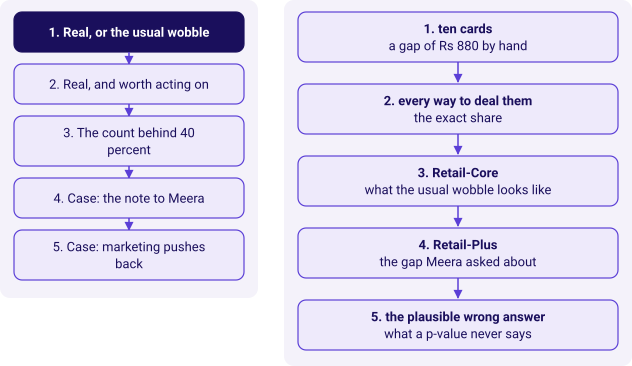

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'Case: the note to Meera', 'Case: marketing pushes back'], lit=0, show=False),
    kit.vflow(["1. ten cards\na gap of Rs 880 by hand",
               "2. every way to deal them\nthe exact share",
               "3. Retail-Core\nwhat the usual wobble looks like",
               "4. Retail-Plus\nthe gap Meera asked about",
               "5. the plausible wrong answer\nwhat a p-value never says"], show=False),
)

## 1. Ten cards: is a gap of Rs 880 surprising?

Five members' Q1 spend and five members' Q2 spend, **invented for the table**, in rupees. The real
gap is the Q1 mean less the Q2 mean. If the quarter made no difference, the labels are arbitrary:
shuffle the ten cards, deal five to each pile, and the gap you get is one chance-only world.

**Predict before you run.** Out of 1,000 shuffles, how many make a gap of Rs 880 or more?
a) about 500, since half of all gaps are positive; b) about 200; c) about 20; d) none, since 880 is
the real gap and shuffling destroys it.

In [3]:
q1_cards = [3400, 2900, 4100, 2500, 3800]
q2_cards = [2200, 3100, 1900, 2700, 2400]


def mean(values):
    return sum(values) / len(values)


real_gap = mean(q1_cards) - mean(q2_cards)
print(f"Q1 mean Rs {mean(q1_cards):,.0f}, Q2 mean Rs {mean(q2_cards):,.0f}, real gap Rs {real_gap:,.0f}")

# One shuffle, by hand in code: mix the cards, deal five and five, recompute the gap.
random.seed(2026)
pool = q1_cards + q2_cards
random.shuffle(pool)
print("one shuffled deal:", pool[:5], "|", pool[5:], f"gap Rs {mean(pool[:5]) - mean(pool[5:]):,.0f}")

Q1 mean Rs 3,340, Q2 mean Rs 2,460, real gap Rs 880
one shuffled deal: [3400, 3100, 4100, 2500, 2700] | [3800, 1900, 2400, 2200, 2900] gap Rs 520


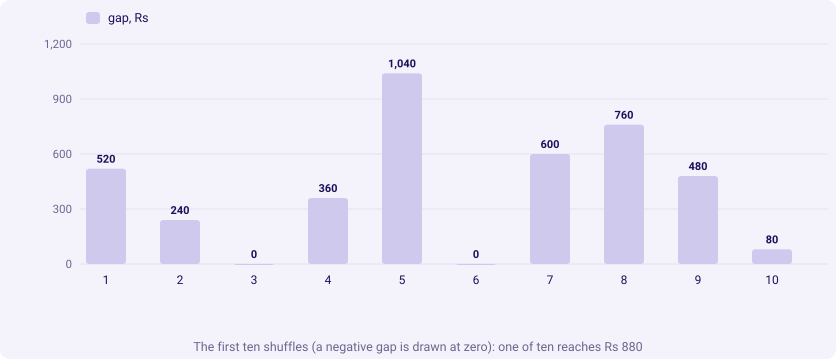

the first ten gaps: [520, 240, -320, 360, 1040, -40, 600, 760, 480, 80]


In [4]:
def shuffle_gaps(q1, q2, times, seed):
    """Deal the pooled values to two piles at random, many times, and keep each gap."""
    random.seed(seed)                  # the same shuffles on every laptop
    pool = q1 + q2                     # all the cards, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)           # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


card_gaps = shuffle_gaps(q1_cards, q2_cards, 1000, seed=2026)
first_ten = [round(g) for g in card_gaps[:10]]
kit.columns([str(i) for i in range(1, 11)], [("gap, Rs", [max(g, 0) for g in first_ten])],
            title="The first ten shuffles (a negative gap is drawn at zero): one of ten reaches Rs 880")
print("the first ten gaps:", first_ten)

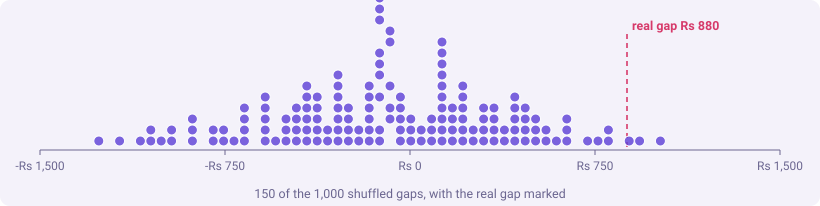

In [5]:
at_least = sum(1 for g in card_gaps if g >= real_gap)
share_cards = at_least / len(card_gaps)
kit.strip(card_gaps[:150], markers=[("real gap", real_gap, "bad")], lo=-1500, hi=1500,
          title="150 of the 1,000 shuffled gaps, with the real gap marked")
kit.stats([("1,000", "shuffles", "the same ten cards"),
           (f"{at_least}", "gaps of Rs 880 or more", "in chance-only worlds"),
           (f"{share_cards:.3f}", "the share", "this is the p-value")])

**What happened.** The answer is c. Twenty-one shuffles in a thousand reached Rs 880, a share of
0.021. Ten hand shuffles showed one in ten, which is why ten is too few: a share needs hundreds of
worlds before it settles. The dots pile up around zero, because most deals mix big and small cards
into both piles, and the real gap sits out on the right edge of the pile.

In [6]:
kit.check("the real gap on the cards is Rs 880", round(real_gap) == 880, f"{real_gap:,.0f}")
kit.check("1,000 shuffles were dealt", len(card_gaps) == 1000)
kit.check("21 of them reach the real gap, with seed 2026", at_least == 21, f"{at_least}")

## 2. Every way to deal ten cards: the exact share

Ten cards split five and five can be dealt in only 252 different ways, so for cards this share can be
counted exactly rather than estimated. That is a check on the shuffle: if the loop is right, its
share should sit close to the exact one.

**Predict before you run.** How close will 1,000 shuffles get to the exact share? a) exactly equal;
b) within about one percentage point; c) within about ten percentage points; d) no relation, since
the shuffle is random.

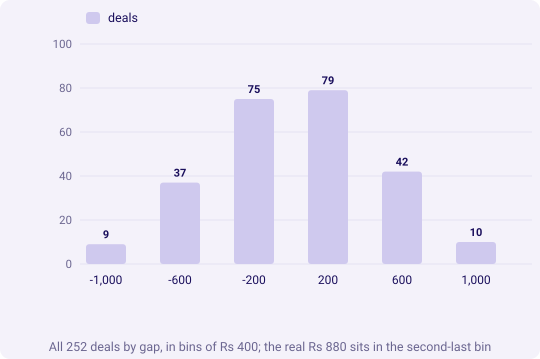

252 deals, exact share 0.0238; the shuffle said 0.0210


In [7]:
import itertools

cards = q1_cards + q2_cards
all_gaps = []
for picked in itertools.combinations(range(10), 5):
    pile_a = [cards[i] for i in picked]
    pile_b = [cards[i] for i in range(10) if i not in picked]
    all_gaps.append(mean(pile_a) - mean(pile_b))

exact = sum(1 for g in all_gaps if g >= real_gap - 1e-9) / len(all_gaps)
labels = ["-1,000", "-600", "-200", "200", "600", "1,000"]
counts = [sum(1 for g in all_gaps if a <= g < a + 400) for a in range(-1200, 1200, 400)]
kit.columns(labels, [("deals", counts)], title="All 252 deals by gap, in bins of Rs 400; the real Rs 880 sits in the second-last bin")
print(f"{len(all_gaps)} deals, exact share {exact:.4f}; the shuffle said {share_cards:.4f}")

**What happened.** The answer is b. Six of the 252 deals reach Rs 880, an exact share of 0.024,
and the shuffle said 0.021. The loop works; with real data the deals run into the millions, so the
shuffle is how the share is found.

In [8]:
kit.check("there are 252 ways to deal ten cards five and five", len(all_gaps) == 252)
kit.check("the shuffle lands within one point of the exact share", abs(exact - share_cards) < 0.01,
          f"exact {exact:.3f}, shuffled {share_cards:.3f}")

## 3. Retail-Core: what the usual wobble looks like

Before judging Retail-Plus, see an ordinary quarter. Retail-Core members also spent a little less in
Q2. The helper below is the measure for the whole day: delivered revenue per member, one number per
member, with a zero for a member who had no delivered order that quarter.

**Predict before you run.** Retail-Core fell by about Rs 110 per member. What share of 5,000 shuffles
will make a gap at least that large? a) under 0.01; b) about 0.05; c) about a third; d) all of them.

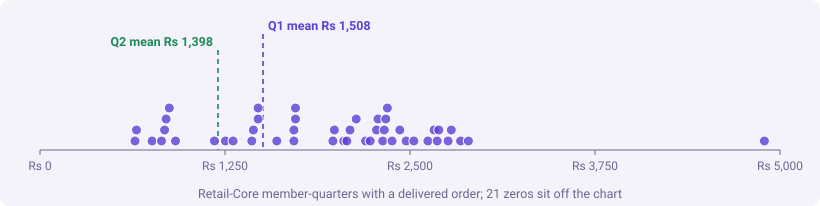

34 members, Q1 mean Rs 1,509, Q2 mean Rs 1,399, gap Rs 110


In [9]:
def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, one number per member."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


core_q1, core_q2 = member_totals("Retail-Core", "Q1"), member_totals("Retail-Core", "Q2")
core_gap = mean(core_q1) - mean(core_q2)
bought = sorted(v for v in core_q1 + core_q2 if v > 0)
kit.strip(bought, markers=[("Q1 mean", mean(core_q1), "plain"), ("Q2 mean", mean(core_q2), "good")],
          lo=0, hi=5000, title=f"Retail-Core member-quarters with a delivered order; {sum(1 for v in core_q1 + core_q2 if v == 0)} zeros sit off the chart")
print(f"{len(core_q1)} members, Q1 mean Rs {mean(core_q1):,.0f}, Q2 mean Rs {mean(core_q2):,.0f}, gap Rs {core_gap:,.0f}")

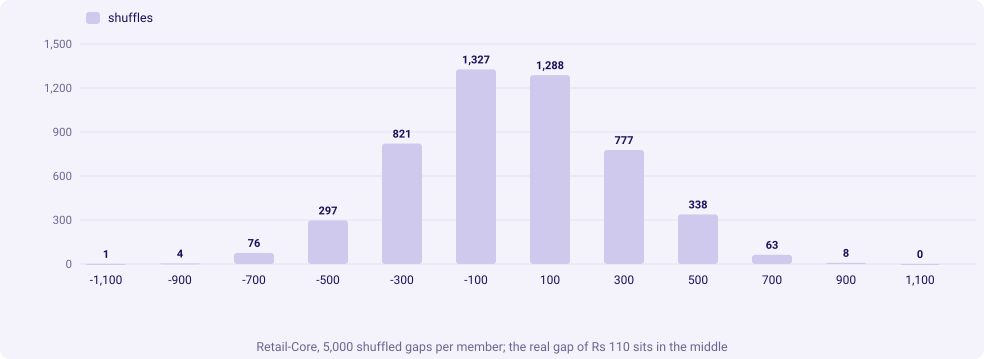

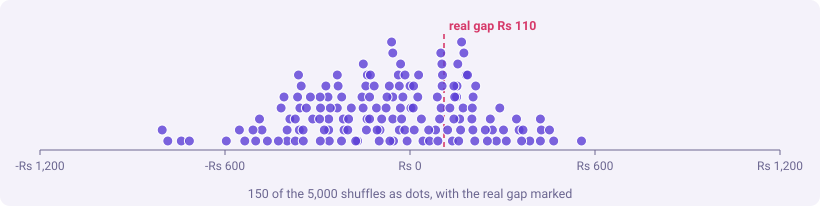

share at least as large: 0.345


In [10]:
def histogram(gaps, step):
    """Count the gaps in bins of one width, for a columns chart of thousands of shuffles."""
    lo = int(min(gaps) // step) * step
    edges = list(range(lo, int(max(gaps)) + step, step))
    counts = [sum(1 for g in gaps if a <= g < a + step) for a in edges]
    labels = [f"{a + step // 2:,}" for a in edges]
    return labels, counts


core_gaps = shuffle_gaps(core_q1, core_q2, 5000, seed=2026)
core_share = sum(1 for g in core_gaps if g >= core_gap) / len(core_gaps)
labels, counts = histogram(core_gaps, 200)
kit.columns(labels, [("shuffles", counts)],
            title=f"Retail-Core, 5,000 shuffled gaps per member; the real gap of Rs {core_gap:,.0f} sits in the middle")
kit.strip(core_gaps[:150], markers=[("real gap", core_gap, "bad")], lo=-1200, hi=1200,
          title="150 of the 5,000 shuffles as dots, with the real gap marked")
print(f"share at least as large: {core_share:.3f}")

**What happened.** The answer is c. About a third of chance-only worlds make a fall of Rs 110 or
more, so Retail-Core's dip is exactly what Meera calls the usual wobble. Keep this picture: it is
what "nothing happened" looks like, and the real gap sits inside the pile.

In [11]:
kit.check("Retail-Core has 34 members in both quarters", len(core_q1) == len(core_q2) == 34)
kit.check("the Retail-Core gap is about Rs 110 a member", round(core_gap) == 110, f"{core_gap:.1f}")
kit.check("chance makes a gap that large often", core_share > 0.25, f"{core_share:.3f}")

## 4. Retail-Plus: the gap Meera asked about

The same loop, pointed at the segment in Meera's question.

**Predict before you run.** Compared with Retail-Core's share of about a third, Retail-Plus's share
will be: a) about the same; b) larger, since Retail-Plus is a smaller segment; c) much smaller, if
its fall is bigger than chance makes; d) impossible to compute, since some members have zeros.

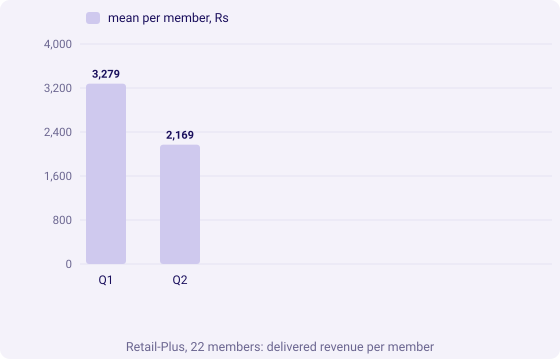

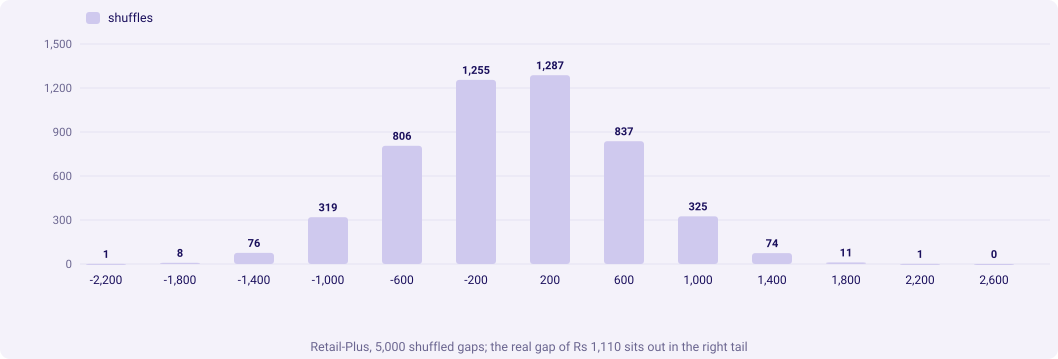

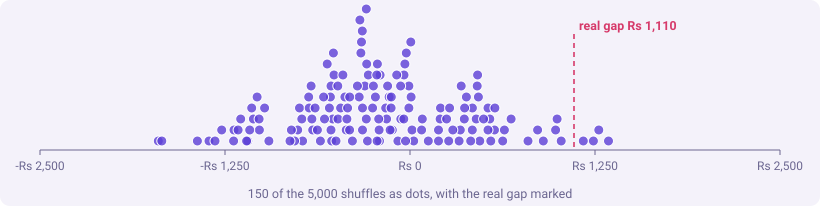

real gap Rs 1,110; 135 of 5,000 at least as large; share 0.027


In [12]:
plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
plus_gap = mean(plus_q1) - mean(plus_q2)
plus_gaps = shuffle_gaps(plus_q1, plus_q2, 5000, seed=2026)
plus_share = sum(1 for g in plus_gaps if g >= plus_gap) / len(plus_gaps)

kit.columns(["Q1", "Q2"], [("mean per member, Rs", [round(mean(plus_q1)), round(mean(plus_q2))])],
            width=560, title=f"Retail-Plus, {len(plus_q1)} members: delivered revenue per member")
labels, counts = histogram(plus_gaps, 400)
kit.columns(labels, [("shuffles", counts)],
            title=f"Retail-Plus, 5,000 shuffled gaps; the real gap of Rs {plus_gap:,.0f} sits out in the right tail")
kit.strip(plus_gaps[:150], markers=[("real gap", plus_gap, "bad")], lo=-2500, hi=2500,
          title="150 of the 5,000 shuffles as dots, with the real gap marked")
print(f"real gap Rs {plus_gap:,.0f}; {sum(1 for g in plus_gaps if g >= plus_gap)} of 5,000 at least as large; share {plus_share:.3f}")

**What happened.** The answer is c. Retail-Plus members delivered Rs 3,279 each in Q1 and Rs 2,169
in Q2, a fall of Rs 1,110 per member. Only 135 of 5,000 shuffles made a fall that large, a share of
0.027, which reads as 0.03 to two places. Against Retail-Core's third, this is a gap chance rarely
makes.

In [13]:
kit.check("Retail-Plus has 22 members in both quarters", len(plus_q1) == len(plus_q2) == 22)
kit.check("the Retail-Plus gap is Rs 1,110 a member", round(plus_gap) == 1110, f"{plus_gap:.1f}")
kit.check("with seed 2026, 135 of 5,000 shuffles reach it", round(plus_share * 5000) == 135, f"{plus_share:.4f}")
kit.check("Retail-Plus beats the wobble that Retail-Core sits inside", plus_share < 0.05 < core_share)

## 5. The plausible wrong answer

**The plausible wrong answer.** The hurried draft turns the share straight into a sentence about
being wrong. Here it is, computed exactly the way it gets written:

In [14]:
draft = f"p = {plus_share:.2f}, so there is a {plus_share:.0%} chance we are wrong about the drop."
print(draft)

p = 0.03, so there is a 3% chance we are wrong about the drop.


**Why it is wrong.** Every one of the 5,000 shuffles was dealt in a world where the quarter made no
difference. The share counts how often *that* world makes a fall this large. It says nothing about
the chance that the real finding is wrong, which depends on things the shuffle never saw: how
plausible a fall was before the data, what else changed, and how many segments were tested.

The check below makes that visible. It builds twenty **invented** segments in which nothing changed
at all, both quarters drawn from the same range, and runs the same test on each. Any segment that
comes back small is a finding that is wrong for certain.

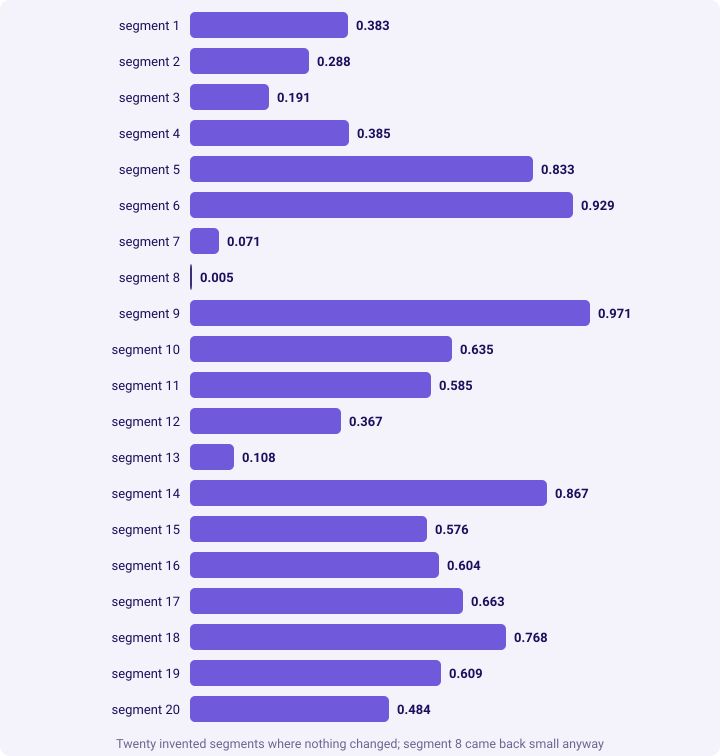

1 of 20 came back at 0.05 or below: [0.005]


In [15]:
invented_shares = []
for s in range(20):
    maker = random.Random(100 + s)                       # invented members, same range both quarters
    values = [maker.randint(1500, 4500) for _ in range(40)]
    q1, q2 = values[:20], values[20:]
    gaps = shuffle_gaps(q1, q2, 1000, seed=2026)
    invented_shares.append(sum(1 for g in gaps if g >= mean(q1) - mean(q2)) / 1000)

kit.bars([(f"segment {i + 1}", round(p, 3)) for i, p in enumerate(invented_shares)],
         lit=[i for i, p in enumerate(invented_shares) if p <= 0.05], fmt=lambda v: f"{v:.3f}",
         title="Twenty invented segments where nothing changed; segment 8 came back small anyway")
small = [p for p in invented_shares if p <= 0.05]
print(f"{len(small)} of 20 came back at 0.05 or below: {small}")

One invented segment came back at 0.005 although nothing happened in it. Its draft note would say
"a 0.5 percent chance we are wrong", and it would be wrong with certainty. The share describes chance
worlds; it never describes the finding.

**The fix.** Say the share, the world it was counted in, and what it lets you conclude:

If nothing had changed between the quarters, a fall of Rs 1,110 per member or more would turn up in about 3 of every 100 shuffles, so we treat the Retail-Plus drop as real.


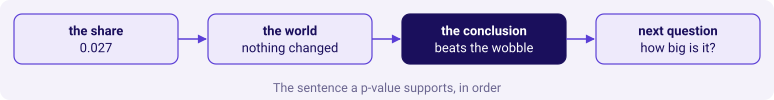

In [16]:
fixed = (f"If nothing had changed between the quarters, a fall of Rs {plus_gap:,.0f} per member or more "
         f"would turn up in about {round(plus_share * 100)} of every 100 shuffles, so we treat the Retail-Plus drop as real.")
print(fixed)
kit.flow(["the share\n" + f"{plus_share:.3f}", "the world\nnothing changed", "the conclusion\nbeats the wobble",
          "next question\nhow big is it?"], lit=2, title="The sentence a p-value supports, in order")
kit.check("the fixed sentence names the chance-only world", "If nothing had changed" in fixed)
kit.check("one of twenty no-change segments still came back small", len(small) == 1, f"{small}")

What changed: the number is the same 0.027, and the claim shrank from "97 percent certain" to "larger
than the usual wobble". That is the claim the evidence carries, and it is the one Kavya signs.

> **Kavya's review.** "Retail-Core's third is the baseline, Retail-Plus's 0.03 is the gap against it,
> and your sentence would still be true if the drop turned out to be a fluke. Now tell me how much
> money it is."

### In the interview

**[S] What does p = 0.03 mean, and not mean?** "It means that if there were no real difference, a
difference at least as large as the one we saw would turn up about 3 times in 100 by chance alone.
It does not mean there is a 3 percent chance the finding is wrong, and it does not say the effect is
large or worth acting on. I would say it as: chance rarely makes a gap this big, so I treat it as
real, and then I size it." The interviewer is listening for the conditional, "if there were no
difference", and for the refusal to call it the probability of being wrong.

**[S] How do you know whether a change in a metric is significant?** "I build a reference for what
chance alone does. The simplest is a shuffle test: pool the values from the two periods, deal them
back at random thousands of times, and see how often the shuffled gap is as large as the real one.
If that share is small, the change is bigger than the usual wobble. Then I check the count behind
it and size the change in money, because significant only means larger than noise." The interviewer
wants a method, a baseline, and the separation of significance from importance.

### Depth: one direction or both

The morning counted falls at least as large, because Meera asked about a drop. Counting falls *or*
rises at least as large asks whether chance makes a move this big in either direction, and it
roughly doubles the share. A note that tested both says so.

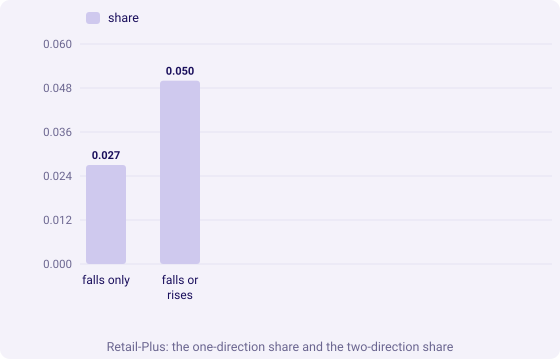

the one-direction share under five other seeds: [0.026, 0.0288, 0.0258, 0.0256, 0.0264]


In [17]:
both = sum(1 for g in plus_gaps if abs(g) >= abs(plus_gap)) / len(plus_gaps)
seeds = [round(sum(1 for g in shuffle_gaps(plus_q1, plus_q2, 5000, seed=s) if g >= plus_gap) / 5000, 4) for s in (1, 2, 3, 4, 5)]
kit.columns(["falls only", "falls or rises"], [("share", [round(plus_share, 3), round(both, 3)])],
            fmt=lambda v: f"{v:.3f}", width=560, title="Retail-Plus: the one-direction share and the two-direction share")
print("the one-direction share under five other seeds:", seeds)
kit.check("counting both directions roughly doubles the share", 1.6 < both / plus_share < 2.4, f"{both:.3f}")
kit.check("another seed moves the share a little and never the verdict", all(0.02 < s < 0.035 for s in seeds), f"{seeds}")

In [18]:
kit.check_summary()
print("Next: notebook 2. The drop beats the wobble; is it worth acting on?")

Next: notebook 2. The drop beats the wobble; is it worth acting on?
